# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
|Mahardika Indra Pratama Ilyasa| 5054251045|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [157]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

# Mengunduh dataset
dataset_path = kagglehub.dataset_download(
    'jamaltariqcheema/pima-indians-diabetes-dataset'
)
print("Dataset berhasil diunduh dari:", dataset_path)

Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
Dataset berhasil diunduh dari: /kaggle/input/pima-indians-diabetes-dataset


In [158]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
csv_path = os.path.join(dataset_path, 'diabetes.csv')
df = pd.read_csv(csv_path)

print("Ukuran dataset :", df.shape)
print("\nLima data pertama:")
display(df.head())

print("=======\nTipe data:")
print(df.dtypes)

print("=======\nJumlah missing value:")
print(df.isnull().sum())

print("=======\nStatistik deskriptif:")
display(df.describe().T)

Ukuran dataset : (768, 9)

Lima data pertama:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


Tipe data:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
Jumlah missing value:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Note:** `isnull().sum()` hanya mendeteksi nilai `NaN` Bukan nilai yang tidak valid secara medis seperti `Pregnancies=0, dsb.`

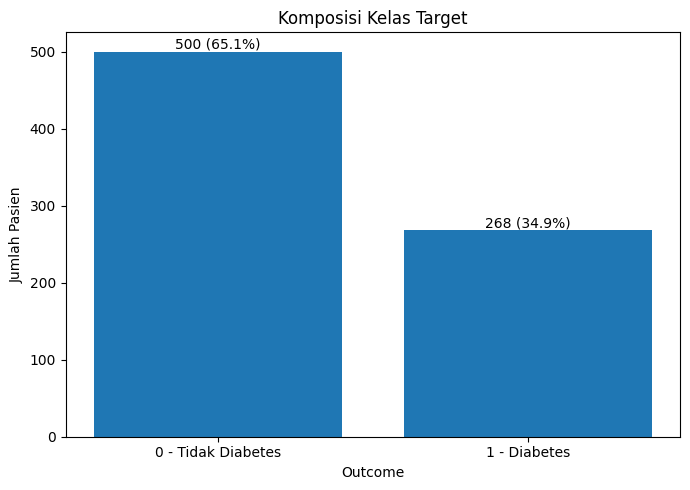

Jumlah kelas 0 : 500
Jumlah kelas 1 : 268


In [159]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
# Distribusi target Outcome
target_count = df['Outcome'].value_counts().sort_index()
target_pct = df['Outcome'].value_counts(normalize=True).sort_index().mul(100)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['0 - Tidak Diabetes', '1 - Diabetes'], target_count.values)
ax.set_title('Komposisi Kelas Target')
ax.set_ylabel('Jumlah Pasien')
ax.set_xlabel('Outcome')

for bar, n, p in zip(bars, target_count.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{n} ({p:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Jumlah kelas 0 : {target_count.loc[0]}")
print(f"Jumlah kelas 1 : {target_count.loc[1]}")

Dapat dilihat bahwa data menunjukkan imbalance

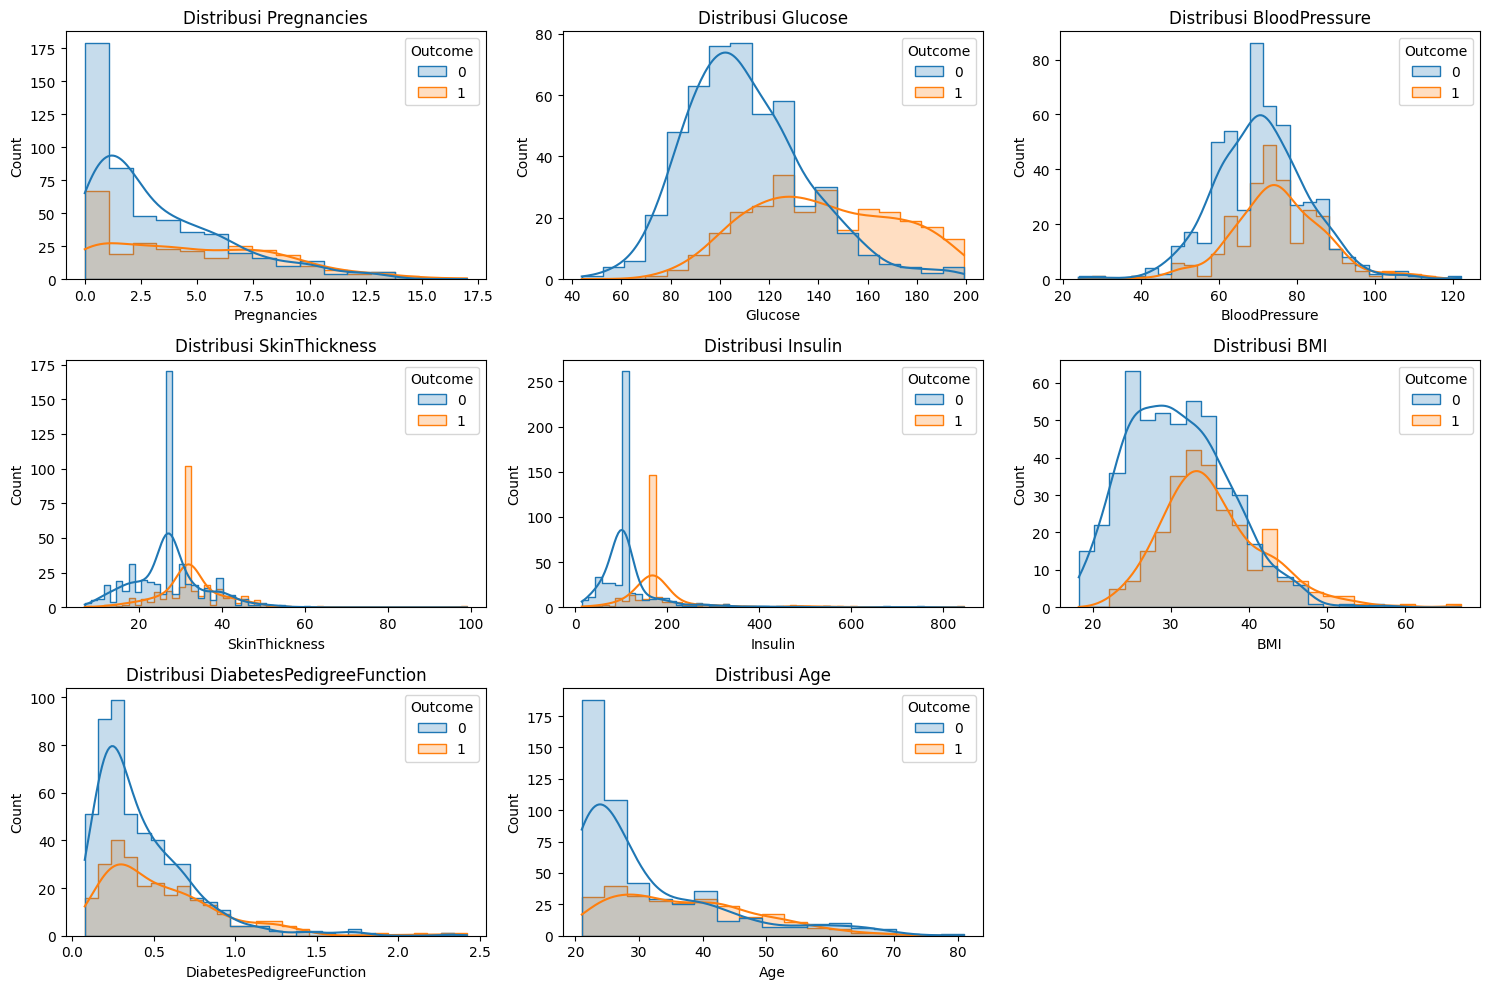

In [160]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = [col for col in df.columns if col.lower() != 'outcome']
plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, element='step')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

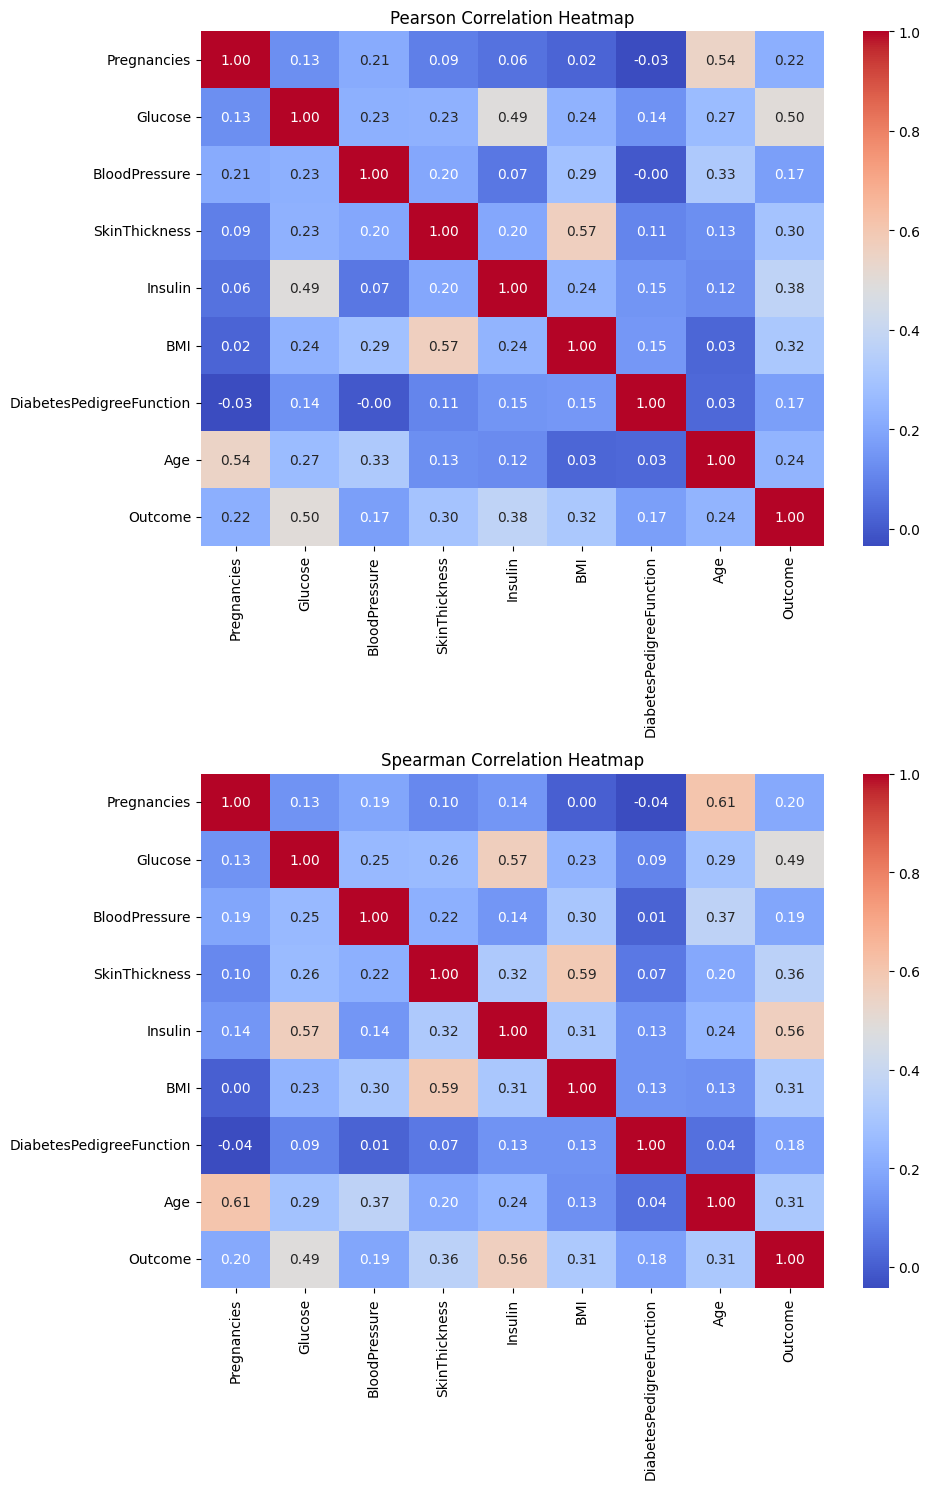

In [161]:
# Tampilkan heatmap korelasi antar fitur.
corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')
fig, axes = plt.subplots(2, 1, figsize=(10, 15))

sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title('Pearson Correlation Heatmap')

sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Spearman Correlation Heatmap')

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [162]:
# 1) Pemeriksaan nilai 0 pada fitur yang menurut instruksi tugas perlu diperiksa.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_summary = pd.DataFrame({
    'Jumlah_0': df[zero_cols].eq(0).sum(),
    'Persentase_0': (df[zero_cols].eq(0).mean() * 100).round(2)
})
print('Perhatikan nilai 0 beriskut:')
display(zero_summary)

Perhatikan nilai 0 beriskut:


,Jumlah_0,Persentase_0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0


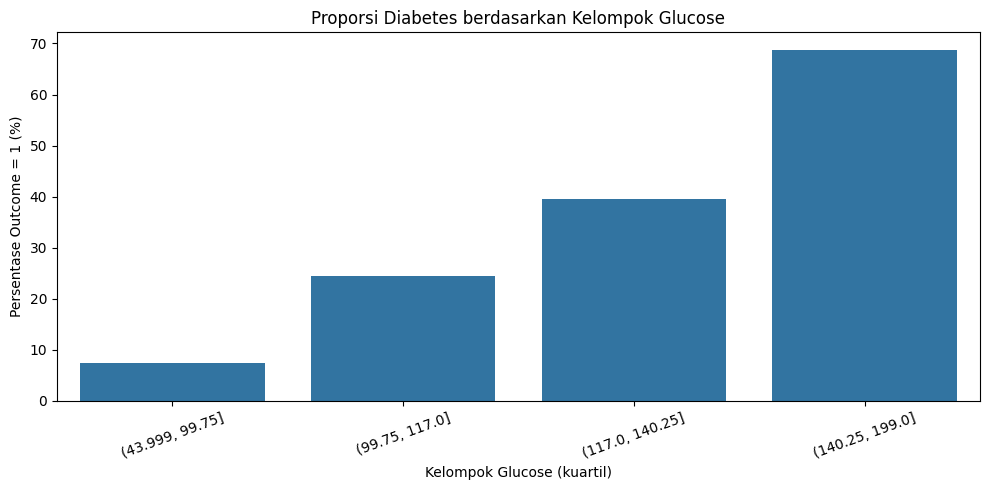

,Glucose,count,Persentase_Diabetes
0,"(43.999, 99.75]",192,7.29
1,"(99.75, 117.0]",197,24.37
2,"(117.0, 140.25]",187,39.57
3,"(140.25, 199.0]",192,68.75


In [163]:
# 2) Proporsi Outcome berdasarkan kelompok Glucose.
glucose_bins = pd.qcut(df['Glucose'], q=4, duplicates='drop')
glucose_rate = (
    df.groupby(glucose_bins, observed=False)['Outcome']
      .agg(['count', 'mean'])
      .reset_index()
)
glucose_rate['Persentase_Diabetes'] = (glucose_rate['mean'] * 100).round(2)

plt.figure(figsize=(10, 5))
sns.barplot(data=glucose_rate, x='Glucose', y='Persentase_Diabetes')
plt.xticks(rotation=20)
plt.xlabel('Kelompok Glucose (kuartil)')
plt.ylabel('Persentase Outcome = 1 (%)')
plt.title('Proporsi Diabetes berdasarkan Kelompok Glucose')
plt.tight_layout()
plt.show()

display(glucose_rate[['Glucose', 'count', 'Persentase_Diabetes']])


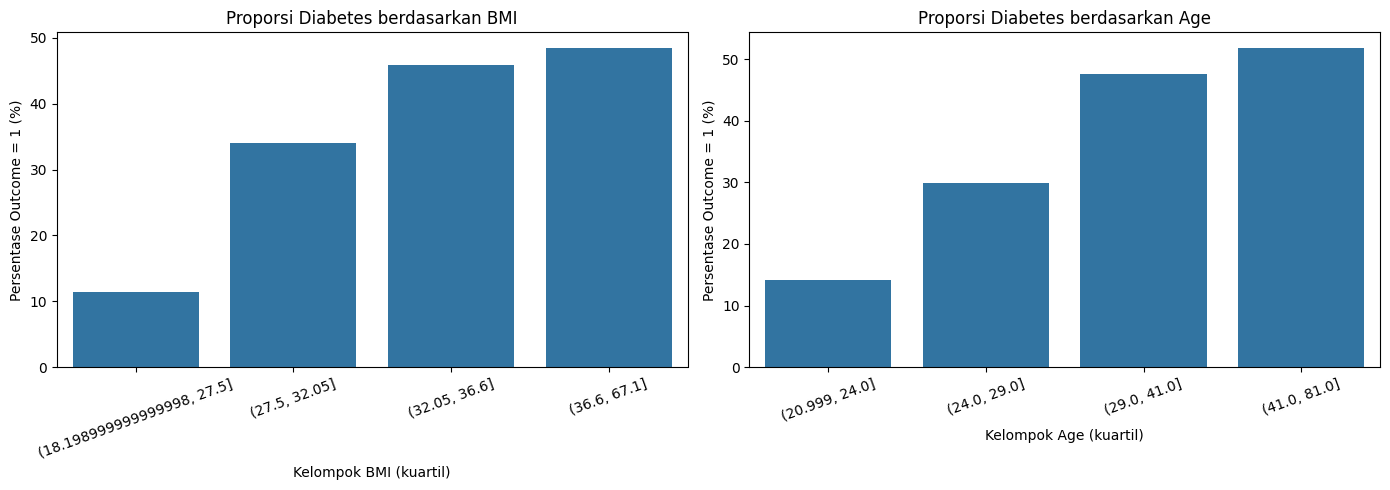

Proporsi Outcome berdasarkan kelompok BMI:


,BMI,count,Persentase_Diabetes
0,"(18.198999999999998, 27.5]",193,11.40
1,"(27.5, 32.05]",191,34.03
2,"(32.05, 36.6]",196,45.92
3,"(36.6, 67.1]",188,48.40


Proporsi Outcome berdasarkan kelompok Age:


,Age,count,Persentase_Diabetes
0,"(20.999, 24.0]",219,14.16
1,"(24.0, 29.0]",177,29.94
2,"(29.0, 41.0]",200,47.50
3,"(41.0, 81.0]",172,51.74


In [164]:
# 3) Proporsi Outcome berdasarkan kelompok BMI dan Age.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

group_results = {}

for ax, col in zip(axes, ['BMI', 'Age']):
    groups = pd.qcut(df[col], q=4, duplicates='drop')
    rate = (
        df.groupby(groups, observed=False)['Outcome']
          .agg(['count', 'mean'])
          .reset_index()
    )
    rate['Persentase_Diabetes'] = (rate['mean'] * 100).round(2)
    group_results[col] = rate

    sns.barplot(data=rate, x=col, y='Persentase_Diabetes', ax=ax)
    ax.set_xlabel(f'Kelompok {col} (kuartil)')
    ax.set_ylabel('Persentase Outcome = 1 (%)')
    ax.set_title(f'Proporsi Diabetes berdasarkan {col}')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

for col, rate in group_results.items():
    print(f'Proporsi Outcome berdasarkan kelompok {col}:')
    display(rate[[col, 'count', 'Persentase_Diabetes']])


# 2. Preprocessing

In [165]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = df[zero_cols].eq(0).sum()

print('Jumlah nilai 0 pada setiap kolom:')
print(zero_counts)

Jumlah nilai 0 pada setiap kolom:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [166]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
X = df.drop(columns='Outcome').copy()
y = df['Outcome'].copy()

X[zero_cols] = X[zero_cols].replace(0, np.nan)

print('Jumlah NaN setelah nilai 0 ditandai sebagai missing:')
print(X.isna().sum())

Jumlah NaN setelah nilai 0 ditandai sebagai missing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


Data sudah bersih

In [167]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Ukuran X_train:', X_train.shape)
print('Ukuran X_test :', X_test.shape)
print('Proporsi kelas train:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print('Proporsi kelas test:')
print(y_test.value_counts(normalize=True).sort_index().round(3))

Ukuran X_train: (614, 8)
Ukuran X_test : (154, 8)
Proporsi kelas train:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64
Proporsi kelas test:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


In [168]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print('Missing value pada X_train setelah imputasi:', np.isnan(X_train_imputed).sum())
print('Missing value pada X_test setelah imputasi :', np.isnan(X_test_imputed).sum())


Missing value pada X_train setelah imputasi: 0
Missing value pada X_test setelah imputasi : 0


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [169]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train)
print("Gaussian Naive Bayes berhasil dilatih.")

Gaussian Naive Bayes berhasil dilatih.


In [170]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = gnb_model.predict(X_test_scaled)
y_prob_gnb = gnb_model.predict_proba(X_test_scaled)[:, 1]


## 3.2 Logistic Regression

In [171]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled, y_train)
print("Logistic Regression berhasil dilatih.")

Logistic Regression berhasil dilatih.


In [172]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_lr = logreg_model.predict(X_test_scaled)
y_prob_lr = logreg_model.predict_proba(X_test_scaled)[:, 1]


# 4. Evaluasi Model

In [173]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
results = pd.DataFrame({
    'Model': ['Gaussian Naive Bayes', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, y_pred_gnb), accuracy_score(y_test, y_pred_lr)],
    'Precision': [precision_score(y_test, y_pred_gnb), precision_score(y_test, y_pred_lr)],
    'Recall': [recall_score(y_test, y_pred_gnb), recall_score(y_test, y_pred_lr)],
    'F1-Score': [f1_score(y_test, y_pred_gnb), f1_score(y_test, y_pred_lr)],
    'AUC': [roc_auc_score(y_test, y_prob_gnb), roc_auc_score(y_test, y_prob_lr)]
})
print('Hasil evaluasi pada test set:')
display(results.round(4))


Hasil evaluasi pada test set:


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Gaussian Naive Bayes,0.7273,0.6034,0.6481,0.6250,0.8017
1,Logistic Regression,0.7078,0.5882,0.5556,0.5714,0.8263


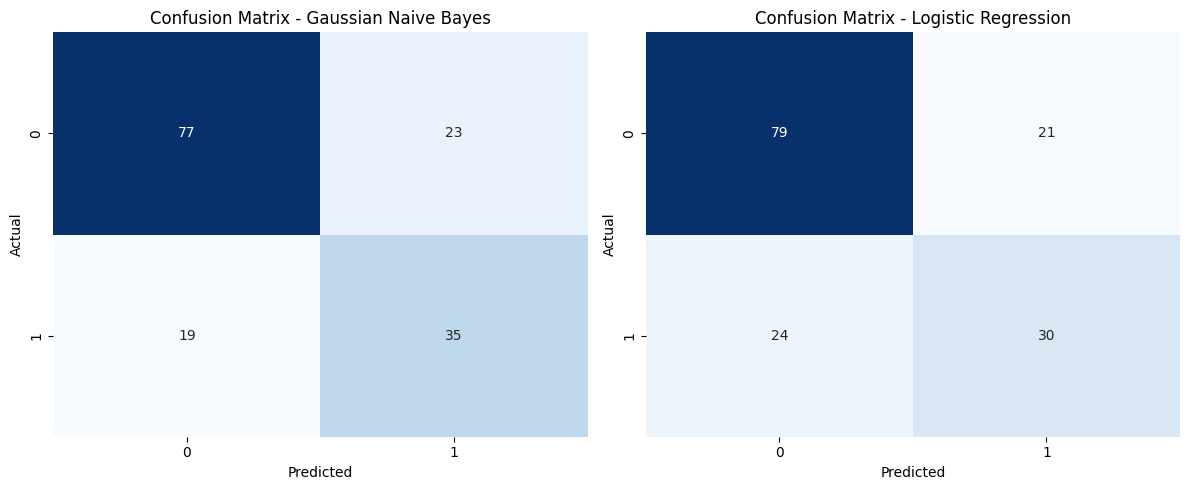

In [174]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix - Gaussian Naive Bayes')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Confusion Matrix - Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


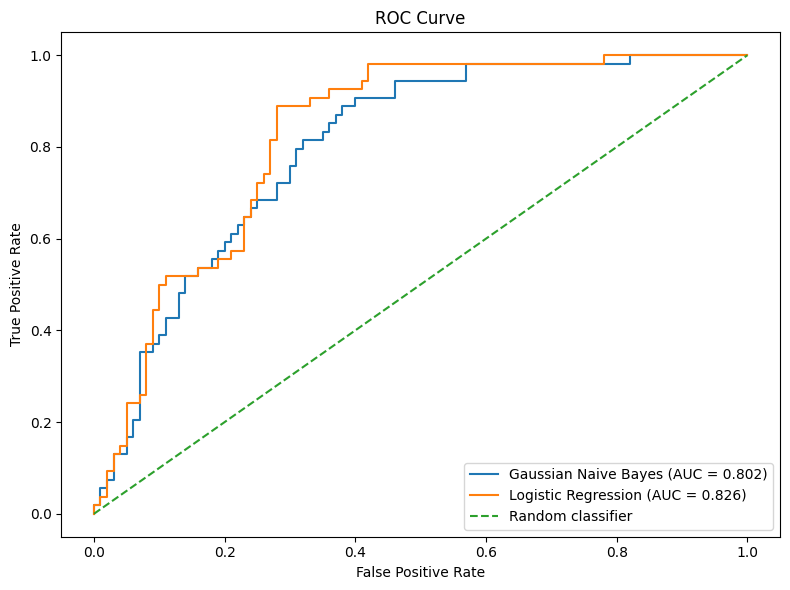

In [175]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_gnb = roc_auc_score(y_test, y_prob_gnb)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian Naive Bayes (AUC = {auc_gnb:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

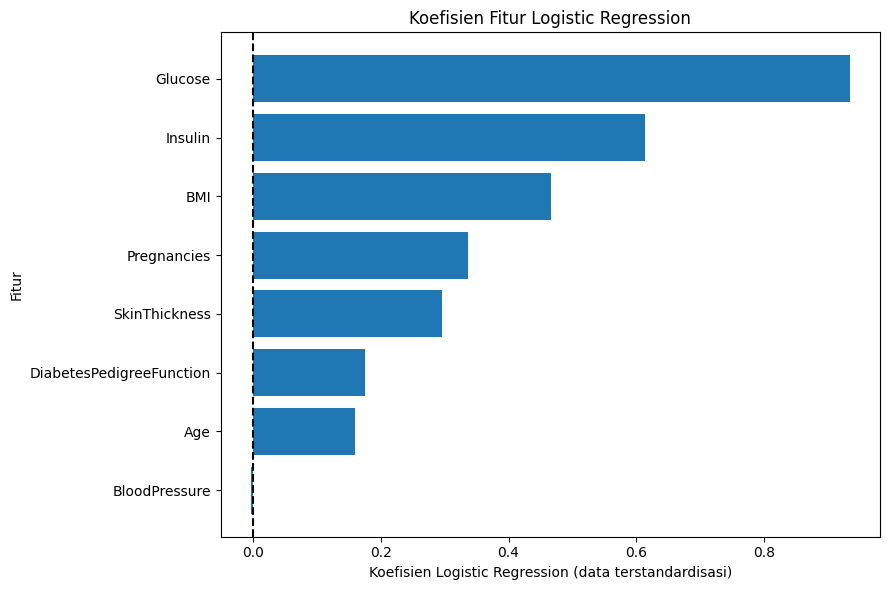

,Feature,Coefficient
0,Glucose,0.9349
1,Insulin,0.6142
2,BMI,0.4661
3,Pregnancies,0.3372
4,SkinThickness,0.2950
5,DiabetesPedigreeFunction,0.1747
6,Age,0.1598
7,BloodPressure,-0.0042


In [177]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg_model.coef_[0]
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 6))
plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1])
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Koefisien Logistic Regression (data terstandardisasi)')
plt.ylabel('Fitur')
plt.title('Koefisien Fitur Logistic Regression')
plt.tight_layout()
plt.show()

display(coef_df.round(4))

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

#### **Analisis**

* **Kualitas Data:** Terdapat banyak angka 0 pada fitur medis (seperti *Glucose* dan *BMI*) yang sebenarnya merupakan *missing value* tersembunyi.
* **Performa Model:** Naive Bayes memberikan hasil dasar yang cepat, namun Logistic Regression lebih unggul dalam interpretasi. Terlihat dari koefisiennya, *Glucose* dan *BMI* adalah faktor risiko terkuat untuk diabetes.
* **Metrik Evaluasi:** Pada kasus diagnosis penyakit, kita harus lebih fokus pada metrik **Recall** (menekan angka *False Negative*) daripada sekadar nilai **Akurasi**.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.


#### **Kesimpulan**

Secara keseluruhan, model Gaussian Naive Bayes dan Logistic Regression mampu mempelajari data dengan cukup baik. Namun, masalah terbesar dalam pemodelan ini adalah **dataset yang *imbalance* (tidak seimbang)**, dengan perbandingan kelas 0 (Tidak Diabetes) berjumlah 500 dan kelas 1 (Diabetes) hanya 268.

Kondisi *imbalance* ini menyebabkan **model menjadi bias terhadap kelas mayoritas**. Model sangat pintar menebak pasien sehat, tetapi kurang sensitif dalam mengenali pasien diabetes. Hal ini membuat tingginya nilai akurasi keseluruhan menjadi menyesatkan, karena metrik *Recall* dan *F1-Score* untuk penderita diabetes justru rendah.

#### **Saran**

Untuk pemodelan yang lebih baik ke depannya, disarankan untuk:

1. **Imputasi Nilai Tepat:** Jangan biarkan fitur medis bernilai 0. Ganti dengan nilai *Mean* atau *Median* agar data lebih representatif.
2. **Penanganan Imbalance Data:** Terapkan teknik penyeimbangan kelas, misalnya menggunakan teknik **SMOTE** (*Oversampling*) agar jumlah data penderita diabetes setara dengan data pasien sehat.
3. **Penyesuaian Ambang Batas (*Threshold Tuning*):** Turunkan batas probabilitas default pada Logistic Regression (misalnya dari 0.5 menjadi 0.3) agar model lebih peka dalam mendeteksi pasien diabetes (meningkatkan *Recall*).